In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
import matplotlib
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
from os import path
path="/content/drive/MyDrive/Machine Learning/praktikum/praktikum 10/data/data_wisata_bogor.csv"

In [14]:
df = pd.read_csv("/content/drive/MyDrive/Machine Learning/praktikum/praktikum 10/data/data_wisata_bogor.csv")
df.info()
df.head()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2093 entries, 0 to 2092
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nama_tempat_wisata  2093 non-null   object 
 1   kategori            2093 non-null   object 
 2   preferensi          2093 non-null   object 
 3   kecamatan           2093 non-null   object 
 4   kabupaten_kota      2093 non-null   object 
 5   rating              2020 non-null   float64
 6   jumlah_rating       2020 non-null   float64
 7   link                2093 non-null   object 
 8   latitude            2093 non-null   float64
 9   longitude           2093 non-null   float64
dtypes: float64(4), object(6)
memory usage: 163.6+ KB


,rating,jumlah_rating,latitude,longitude
count,2020.000000,2020.000000,2093.000000,2093.000000
mean,4.560050,742.242079,-6.576100,106.812599
std,0.364079,3957.731371,0.106061,0.148765
min,1.000000,1.000000,-6.887042,106.017801
25%,4.400000,9.000000,-6.667331,106.717605
50%,4.600000,39.000000,-6.587488,106.809307
75%,4.800000,230.250000,-6.488292,106.915601
max,5.000000,101936.000000,-6.214557,107.797893


In [20]:
X = df[['latitude', 'longitude']].values
from sklearn.cluster import DBSCAN

EPS_VALUE = 0.5
MIN_SAMPLES_VALUE = 5

db = DBSCAN(eps=EPS_VALUE, min_samples=MIN_SAMPLES_VALUE).fit(X)
df['Cluster'] = db.labels_
n_clusters_ = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_noise_ = list(db.labels_).count(-1)

print(f"Jumlah Klaster Teridentifikasi: {n_clusters_}")
print(f"Jumlah Titik Noise (-1): {n_noise_}")

Jumlah Klaster Teridentifikasi: 1
Jumlah Titik Noise (-1): 0


In [21]:
df_clustered = df[df['Cluster'] != -1]
X_clustered = df_clustered[['latitude', 'longitude']].values
labels_clustered = df_clustered['Cluster'].values

plt.figure(figsize=(12, 10))

unique_labels = sorted(set(labels_clustered))
colors = matplotlib.colormaps.get_cmap('Spectral')

<Figure size 1200x1000 with 0 Axes>

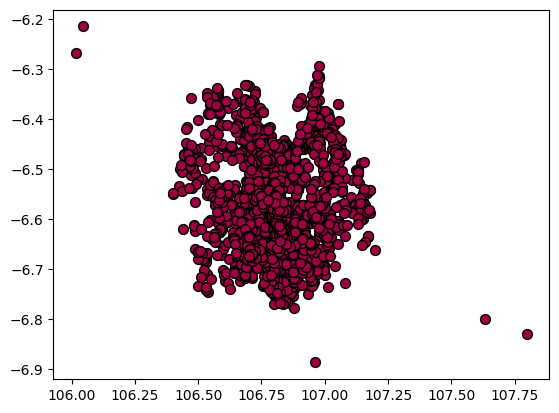

In [22]:
for k in unique_labels:
    class_member_mask = (labels_clustered == k)
    xy = X_clustered[class_member_mask]
    plt.scatter(xy[:, 1], xy[:, 0], s=50, marker='o', color=colors(k), edgecolor='k', label=f'Klaster {k} (n={len(xy)})')

/tmp/ipython-input-635929699.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Klaster", loc='upper left', bbox_to_anchor=(1, 1))


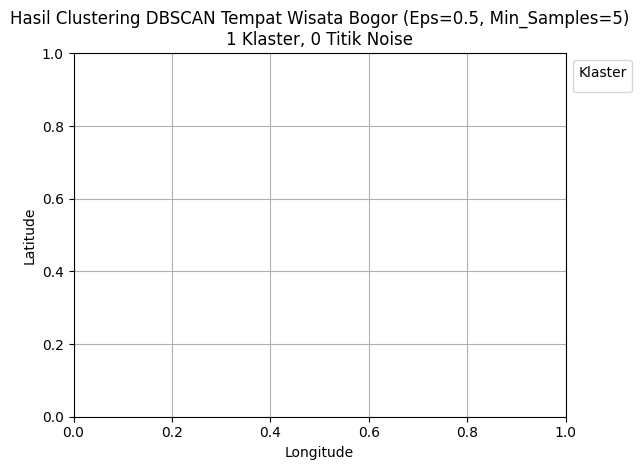

In [23]:
# Plot titik-titik Noise (jika ada)
if n_noise_ > 0:
    df_noise = df[df['Cluster'] == -1]
    xy_noise = df_noise[['latitude', 'longitude']].values
    plt.scatter(xy_noise[:, 1], xy_noise[:, 0], s=20, marker='.', color='gray', label=f'Noise (-1) (n={n_noise_})', alpha=0.5)

plt.title(f'Hasil Clustering DBSCAN Tempat Wisata Bogor (Eps={EPS_VALUE}, Min_Samples={MIN_SAMPLES_VALUE})\n{n_clusters_} Klaster, {n_noise_} Titik Noise')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title="Klaster", loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.tight_layout()

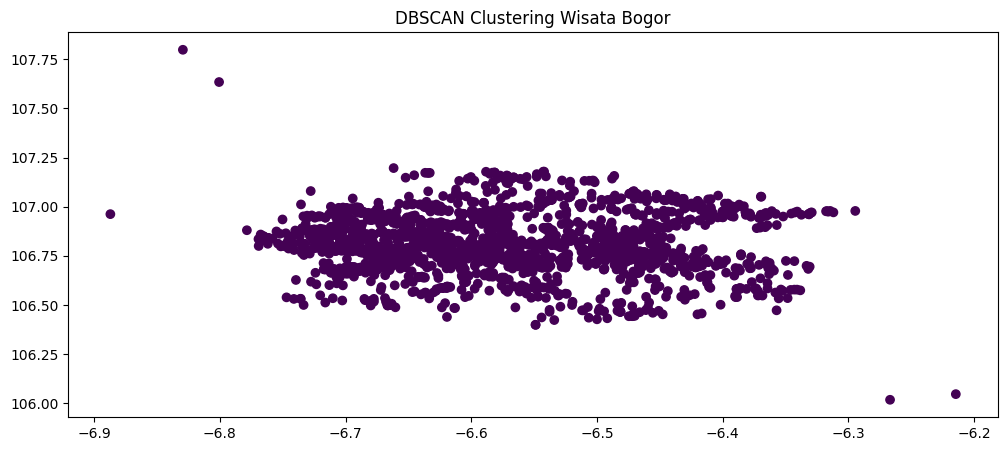

In [24]:
plt.figure(figsize=(12,5))   # lebih panjang (12) dan tidak terlalu tinggi
plt.scatter(X[:,0], X[:,1], c=df['Cluster'])
plt.title("DBSCAN Clustering Wisata Bogor")

plt.savefig("dbscan_wisata_bogor.png")
plt.show()
